# O Neurônio Artificial: O Perceptron
- Baseado no algoritmo de Frank Rosenblatt (1958) e no modelo matemático de McCulloch-Pitts (1943).
- É um **classificador linear binário**:
  - Classifica dados calculando a soma ponderada: $z = w_1 \cdot x_1 + w_2 \cdot x_2 + w_0$ (onde $w_0$ é o *bias/intercept*).
  - Se $z \ge 0 \rightarrow$ Classe 1; se $z < 0 \rightarrow$ Classe 0.
  - **Condição essencial:** As classes precisam ser **linearmente separáveis** no plano.

In [1]:
# Bibliotecas
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import Perceptron
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Perceptron.html

### 1. Carregando o Dataset de Vinhos (`load_wine`)
- Vamos classificar dois tipos de vinho (Classe 0 e Classe 1).
- Para permitir a visualização 2D da reta de decisão, utilizaremos apenas 2 variáveis químicas:
  1. `color_intensity` (Intensidade da cor)
  2. `flavanoids` (Concentração de flavonoides)

In [3]:
from sklearn.datasets import load_wine

X_wine, y_wine = load_wine(return_X_y=True, as_frame=True)

# Selecionamos as Classes 0 e 2 (totalmente separáveis por essas duas métricas)
filtro_classes = y_wine.isin([0, 2])
colunas_selecionadas = ['color_intensity', 'flavanoids']

X = X_wine.loc[filtro_classes, colunas_selecionadas]
y = y_wine.loc[filtro_classes]

# Ajustando o target para 0 e 1 (o Perceptron trabalha de forma binária)
y = (y == 2).astype(int)

print(X.head(3))

print(y.head(3))

   color_intensity  flavanoids
0             5.64        3.06
1             4.38        2.76
2             5.68        3.24
0    0
1    0
2    0
Name: target, dtype: int64


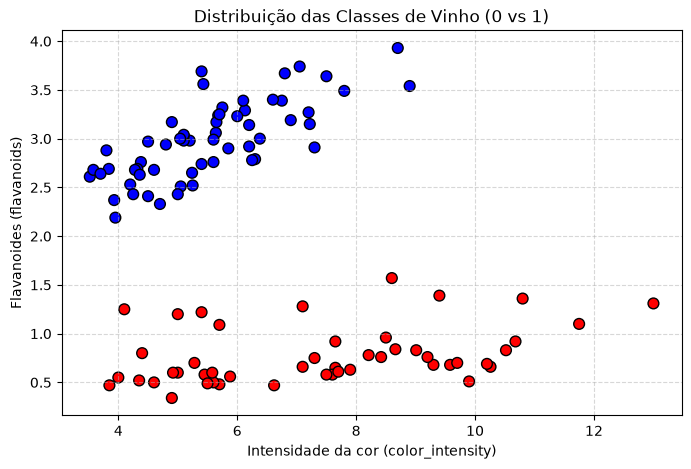

In [4]:
# Gráfico de dispersão para verificar se os dados são linearmente separáveis
fig, ax = plt.subplots(figsize=(8, 5))

scatter = ax.scatter(X['color_intensity'], X['flavanoids'], c=y, cmap='bwr', edgecolors='k', s=60)

ax.set_xlabel('Intensidade da cor (color_intensity)')
ax.set_ylabel('Flavanoides (flavanoids)')
ax.set_title('Distribuição das Classes de Vinho (0 vs 1)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [5]:
# Divisão entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Instanciando e treinando o Perceptron
clf = Perceptron(tol=1e-3, random_state=42, eta0=0.1)
clf.fit(X_train, y_train)

# Avaliação com a Matriz de Confusão
y_pred = clf.predict(X_test)
print("Matriz de Confusão no Conjunto de Teste:")
print(confusion_matrix(y_test, y_pred))

Matriz de Confusão no Conjunto de Teste:
[[19  0]
 [ 0 14]]


In [6]:
# Extraindo os pesos aprendidos (w1, w2) e o viés (w0)
w1 = clf.coef_[0][0]
w2 = clf.coef_[0][1]
w0 = clf.intercept_[0]

print(f"Equação do hiperplano aprendida: ({w1:.3f} * x1) + ({w2:.3f} * x2) + ({w0:.3f}) = 0")

Equação do hiperplano aprendida: (0.811 * x1) + (-2.013 * x2) + (-0.100) = 0


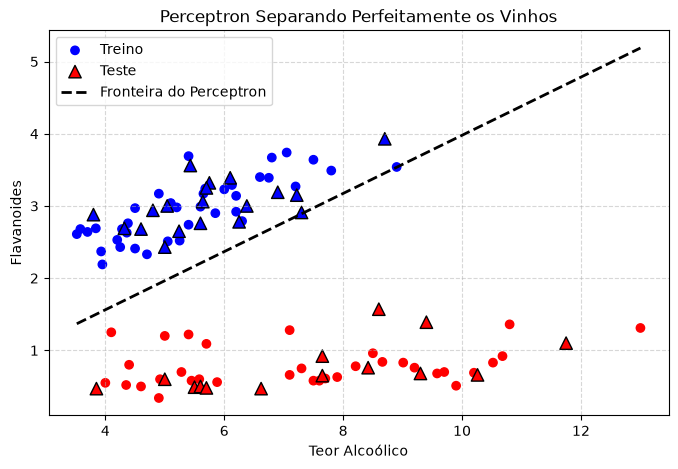

In [7]:
# Plotando a reta separadora: x2 = (-w1 * x1 - w0) / w2
fig, ax = plt.subplots(figsize=(8, 5))

# Plot dos pontos de treino e teste
ax.scatter(X_train['color_intensity'], X_train['flavanoids'], c=y_train, cmap='bwr', marker='o', label='Treino')
ax.scatter(X_test['color_intensity'], X_test['flavanoids'], c=y_test, cmap='bwr', marker='^', edgecolors='k', s=80, label='Teste')

# Gerando os pontos da reta de decisão
x_valores = np.linspace(X['color_intensity'].min(), X['color_intensity'].max(), 100)
y_valores = (-w1 * x_valores - w0) / w2

ax.plot(x_valores, y_valores, color='black', linestyle='--', linewidth=2, label='Fronteira do Perceptron')

ax.set_xlabel('Teor Alcoólico')
ax.set_ylabel('Flavanoides')
ax.set_title('Perceptron Separando Perfeitamente os Vinhos')
ax.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

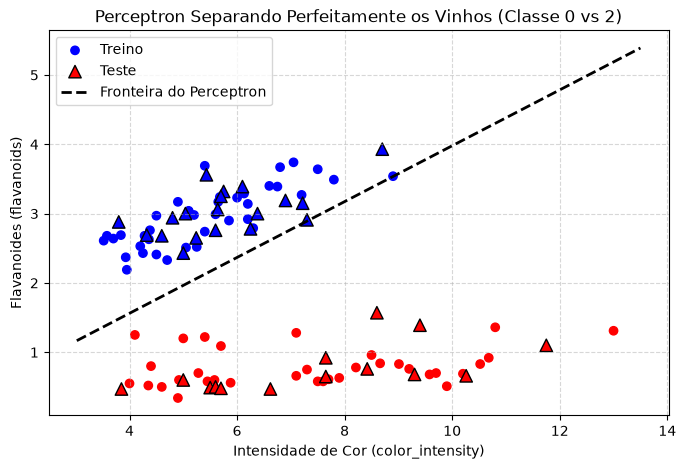

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

# Plot dos pontos de treino e teste
ax.scatter(X_train['color_intensity'], X_train['flavanoids'], c=y_train, cmap='bwr', marker='o', label='Treino')
ax.scatter(X_test['color_intensity'], X_test['flavanoids'], c=y_test, cmap='bwr', marker='^', edgecolors='k', s=80, label='Teste')

# Gerando a reta de decisão: x2 = (-w1 * x1 - w0) / w2
x_valores = np.linspace(X['color_intensity'].min() - 0.5, X['color_intensity'].max() + 0.5, 100)
y_valores = (-w1 * x_valores - w0) / w2

ax.plot(x_valores, y_valores, color='black', linestyle='--', linewidth=2, label='Fronteira do Perceptron')

ax.set_xlabel('Intensidade de Cor (color_intensity)')
ax.set_ylabel('Flavanoides (flavanoids)')
ax.set_title('Perceptron Separando Perfeitamente os Vinhos (Classe 0 vs 2)')
ax.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

---
## 2. A Queda Histórica: O Problema do OU Exclusivo (XOR)
O Perceptron aprende apenas **uma única reta divisora**. Quando os dados são intercalados (não linearmente separáveis), um único neurônio falha completamente.

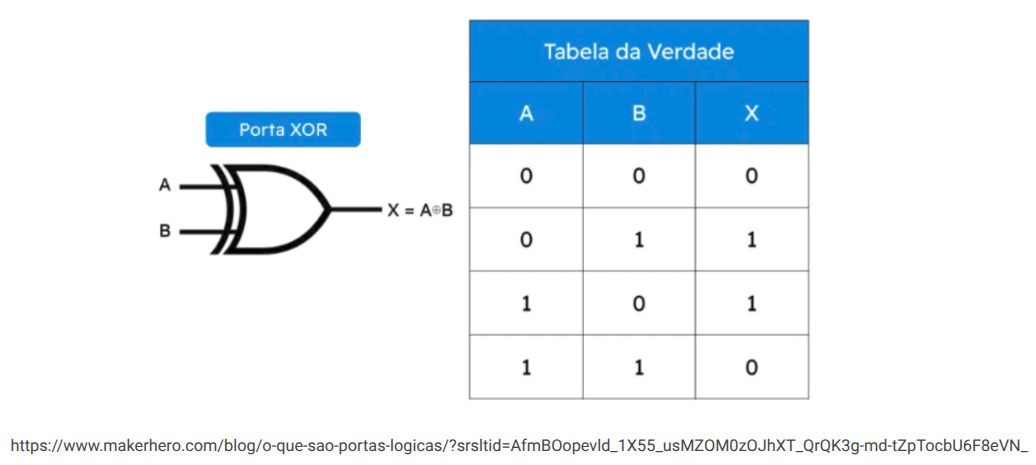

In [9]:
# Tabela verdade do XOR
dados_xor = pd.DataFrame({
    'x1': [0, 0, 1, 1],
    'x2': [0, 1, 0, 1],
    'y':  [0, 1, 1, 0]  # Saídas iguais geram 0, saídas diferentes geram 1
})

X_xor = dados_xor[['x1', 'x2']]
y_xor = dados_xor['y']

# Treinando o Perceptron no XOR
clf_xor = Perceptron(tol=1e-3, random_state=42)
clf_xor.fit(X_xor, y_xor)

print("Previsões do Perceptron para o XOR:", clf_xor.predict(X_xor))
print("Valores Reais esperados:           ", list(y_xor))
print("\nAcurácia do Perceptron no XOR: 50% (equivalente a jogar uma moeda).")

Previsões do Perceptron para o XOR: [0 0 0 0]
Valores Reais esperados:            [0, 1, 1, 0]

Acurácia do Perceptron no XOR: 50% (equivalente a jogar uma moeda).


## Vamos tentar resolver o problema com Tensorflow

<br>

### **Anaconda**

### Criar um ambiente conda padrão com as bibliotecas standard
conda create -n venv_tf python=3.11 anaconda -y

### Ativa o ambiente conda
conda activate venv_tf

### Atualiza o pip
pip install --upgrade pip

### Install tensorflow
pip install tensorflow

https://www.tensorflow.org/install/pip?hl=pt-br


In [11]:
import warnings

warnings.filterwarnings('ignore')

from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

In [12]:
modelo_mlp = Sequential([
    # 'tanh' evita o problema de neurônios mortos e vai convergir mais rápido no XOR
    Dense(4, input_dim=2, activation='tanh'),
    Dense(1, activation='sigmoid')
])

# Taxa de aprendizado em 0.05 para convergir rápido
modelo_mlp.compile(
    optimizer=Adam(learning_rate=0.05),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 200 época
modelo_mlp.fit(X_xor, y_xor, epochs=200, verbose=0)

W0000 00:00:1787792215.292544   99148 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [13]:
probabilidades = modelo_mlp.predict(X_xor)
predicoes_finais = (probabilidades >= 0.5).astype(int).flatten()

print("Previsões da Rede Neural (MLP):", predicoes_finais)
print("Valores Reais esperados:        ", list(y_xor))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Previsões da Rede Neural (MLP): [0 1 1 0]
Valores Reais esperados:         [0, 1, 1, 0]
